In [1]:
#Import the libraries 
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay, r2_score)
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.inspection import permutation_importance

In [22]:
#Load the dataset
churn=pd.read_csv("netflix_customer_churn_clean.csv")
header=pd.read_csv("netflix_titles_clean.csv")

# A. Customer churn

## Descriptive statistics

In [7]:

print("A1. CHURN - DESCRIPTIVE STATISTICS (mean / median / mode)")

num_c = ["age", "watch_hours", "last_login_days", "monthly_fee",
         "number_of_profiles", "avg_watch_time_per_day"]
desc = churn[num_c].agg(["mean", "median", lambda s: s.mode().iloc[0], "std",
                       "min", "max", "skew"]).T
desc.columns = ["mean", "median", "mode", "std", "min", "max", "skew"]
print(desc.round(2))

print("\nMode of categorical columns:")
cat_c = ["gender", "subscription_type", "region", "device",
         "payment_method", "favorite_genre"]
for c in cat_c:
    print(f"  {c:20s} -> {churn[c].mode().iloc[0]}")

print(f"\nOverall churn rate: {churn.churned.mean():.1%}")
print(f"Rows flagged 'impossible (>24 h/day)': "
      f"{(churn.avg_watch_time_flag != 'ok').sum()}  (excluded from ML)")

print("\nMean/median by churn status:")
print(churn.groupby("churned_label")[num_c].agg(["mean", "median"]).T.round(2))

print("\nChurn rate by segment:")
for c in cat_c:
    print(f"\n{c}\n", (churn.groupby(c).churned.mean().sort_values(ascending=False)
                       .mul(100).round(1).astype(str) + "%").to_string())

A1. CHURN - DESCRIPTIVE STATISTICS (mean / median / mode)
                         mean  median   mode    std    min     max   skew
age                     43.85   44.00  63.00  15.50  18.00   70.00   0.01
watch_hours             11.65    8.00   0.24  12.01   0.01  110.40   2.26
last_login_days         30.09   30.00  37.00  17.54   0.00   60.00  -0.03
monthly_fee             13.68   13.99  17.99   3.69   8.99   17.99  -0.14
number_of_profiles       3.02    3.00   5.00   1.42   1.00    5.00  -0.02
avg_watch_time_per_day   0.87    0.29   0.01   2.62   0.00   98.42  15.83

Mode of categorical columns:
  gender               -> Female
  subscription_type    -> Premium
  region               -> South America
  device               -> Tablet
  payment_method       -> Debit Card
  favorite_genre       -> Drama

Overall churn rate: 50.3%
Rows flagged 'impossible (>24 h/day)': 10  (excluded from ML)

Mean/median by churn status:
churned_label                  Active  Churned
age                

## Statistical tests + plots

In [8]:
# Statistical tests
def save(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png", bbox_inches="tight")
    plt.close()

# Statistical tests
print("A2. CHURN - STATISTICAL TESTS")
num_features = ["age", "watch_hours", "last_login_days", "number_of_profiles"]

for c in num_features:
    a = churn.loc[churn.churned == 1, c]
    b = churn.loc[churn.churned == 0, c]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f"t-test {c:20s} churned={a.mean():7.2f} active={b.mean():7.2f}  p={p:.4f}")

for c in cat_c:
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(churn[c], churn.churned))
    print(f"chi2   {c:20s} chi2={chi2:7.2f}  p={p:.4f}")

A2. CHURN - STATISTICAL TESTS
t-test age                  churned=  43.79 active=  43.90  p=0.8037
t-test watch_hours          churned=   5.92 active=  17.45  p=0.0000
t-test last_login_days      churned=  38.31 active=  21.77  p=0.0000
t-test number_of_profiles   churned=   2.80 active=   3.25  p=0.0000
chi2   gender               chi2=   0.65  p=0.7225
chi2   subscription_type    chi2= 133.28  p=0.0000
chi2   region               chi2=   2.65  p=0.7531
chi2   device               chi2=   1.45  p=0.8362
chi2   payment_method       chi2=  96.91  p=0.0000
chi2   favorite_genre       chi2=   6.97  p=0.3236


## Plots

In [9]:
# 1. Distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), num_c):
    sns.histplot(churn[c], kde=True, ax=ax, bins=30)
    ax.axvline(churn[c].mean(), color="red", ls="--", label="mean")
    ax.axvline(churn[c].median(), color="green", ls="-.", label="median")
    ax.set_title(c)
    ax.legend()
plt.suptitle("Churn dataset - distributions (mean vs median)")
save("A1_distributions")

# 2. Categorical Churn %
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), cat_c):
    r = churn.groupby(c).churned.mean().sort_values()
    r.mul(100).plot.barh(ax=ax, color=sns.color_palette("deep")[3])
    ax.axvline(churn.churned.mean() * 100, color="k", ls="--")
    ax.set_title(f"Churn % by {c}")
    ax.set_xlabel("%")
save("A2_churn_by_category")

# 3. Boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), num_c):
    sns.boxplot(data=churn, x="churned_label", y=c, ax=ax)
    ax.set_title(c)
plt.suptitle("Numeric features by churn status")
save("A3_boxplots")

# 4. Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(churn[num_c + ["churned"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Churn dataset - Pearson correlation")
save("A4_corr_heatmap")

## Customer churn - correlation

In [10]:
print("=== A3. CHURN - CORRELATION WITH TARGET ===")
print(churn[num_c + ["churned"]].corr()["churned"].drop("churned")
      .sort_values(key=abs, ascending=False).round(3))

print("\nSpearman:")
print(churn[num_c + ["churned"]].corr(method="spearman")["churned"]
      .drop("churned").sort_values(key=abs, ascending=False).round(3))

=== A3. CHURN - CORRELATION WITH TARGET ===
watch_hours              -0.480
last_login_days           0.472
avg_watch_time_per_day   -0.273
number_of_profiles       -0.159
monthly_fee              -0.152
age                      -0.004
Name: churned, dtype: float64

Spearman:
avg_watch_time_per_day   -0.734
watch_hours              -0.541
last_login_days           0.471
number_of_profiles       -0.159
monthly_fee              -0.148
age                      -0.004
Name: churned, dtype: float64


## Customer churn - machine learning

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans

# Define random seed and helper functions
SEED = 42

def header(title):
    """Prints a styled section header."""
    print(f"\n{'=' * 50}\n{title}\n{'=' * 50}")

def save(filename):
    """Saves the active matplotlib plot."""
    plt.savefig(f"{filename}.png", bbox_inches="tight")
    plt.close()

# --- A4. CHURN - MACHINE LEARNING ---
header("A4. CHURN - MACHINE LEARNING")

# Clean data and define feature sets
clean = churn[churn.avg_watch_time_flag == "ok"].copy()

feat_num = [
    "age", "watch_hours", "last_login_days", "monthly_fee",
    "number_of_profiles", "avg_watch_time_per_day"
]
feat_cat = [
    "gender", "subscription_type", "region", "device",
    "payment_method", "favorite_genre"
]

X, y = clean[feat_num + feat_cat], clean["churned"]  # churned_label dropped (leakage)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

# Preprocessing pipeline
pre = ColumnTransformer([
    ("num", StandardScaler(), feat_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feat_cat)
])

# Models evaluation setup
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, random_state=SEED, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
fitted, rows = {}, []

plt.figure(figsize=(7, 6))
ax = plt.gca()

for name, m in models.items():
    pipe = Pipeline([("pre", pre), ("m", m)])
    
    # 5-fold CV AUC evaluated on training data
    cvauc = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="roc_auc").mean()
    
    # Fit pipeline on full training set
    pipe.fit(Xtr, ytr)
    fitted[name] = pipe
    
    # Evaluate on test set
    p = pipe.predict_proba(Xte)[:, 1]
    rows.append([
        name, 
        accuracy_score(yte, pipe.predict(Xte)),
        roc_auc_score(yte, p), 
        cvauc
    ])
    RocCurveDisplay.from_predictions(yte, p, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--")
ax.set_title("ROC curves - churn prediction")
save("A5_roc")

# Print model comparison table & baseline
res = pd.DataFrame(rows, columns=["model", "test_acc", "test_auc", "cv5_auc"]).round(3)
print(res.to_string(index=False))
print(f"\nBaseline accuracy (majority class): {max(y.mean(), 1 - y.mean()):.3f}")

# Best Model Evaluation (Random Forest)
best = fitted["Random Forest"]
print("\nRandom Forest report:")
print(classification_report(yte, best.predict(Xte), target_names=["Active", "Churned"]))

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(yte, best.predict(Xte)), 
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Active", "Churned"], 
    yticklabels=["Active", "Churned"]
)
plt.title("Confusion matrix - Random Forest")
save("A6_confusion")

# Permutation Feature Importance
pi = permutation_importance(
    best, Xte, yte, n_repeats=10, random_state=SEED, scoring="roc_auc", n_jobs=-1
)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values()

plt.figure(figsize=(7, 5))
imp.plot.barh()
plt.title("Permutation importance (drop in AUC)")
save("A7_importance")
print("\nPermutation importance:\n", imp.sort_values(ascending=False).round(4))

# --- Customer Segmentation (Unsupervised) ---
seg_X = StandardScaler().fit_transform(
    clean[["age", "watch_hours", "last_login_days", "number_of_profiles", "monthly_fee"]]
)
clean["segment"] = KMeans(4, n_init=10, random_state=SEED).fit_predict(seg_X)

print("\nKMeans segments (profile means + churn rate):")
print(
    clean.groupby("segment")[["age", "watch_hours", "last_login_days", "number_of_profiles", "monthly_fee", "churned"]]
    .mean().round(2)
    .assign(n=clean.segment.value_counts().sort_index())
)


A4. CHURN - MACHINE LEARNING
              model  test_acc  test_auc  cv5_auc
Logistic Regression     0.889     0.961    0.969
      Random Forest     0.974     0.995    0.996
  Gradient Boosting     0.987     0.998    0.999

Baseline accuracy (majority class): 0.504

Random Forest report:
              precision    recall  f1-score   support

      Active       0.98      0.97      0.97       619
     Churned       0.97      0.98      0.97       629

    accuracy                           0.97      1248
   macro avg       0.97      0.97      0.97      1248
weighted avg       0.97      0.97      0.97      1248


Permutation importance:
 avg_watch_time_per_day    0.1558
last_login_days           0.0499
watch_hours               0.0443
number_of_profiles        0.0317
payment_method            0.0164
subscription_type         0.0072
monthly_fee               0.0041
favorite_genre            0.0001
region                    0.0001
age                       0.0001
device                   


==================== B3. TITLES - MACHINE LEARNING ====================

Movie vs TV Show (LogReg + TF-IDF): acc=0.954 AUC=0.981
              precision    recall  f1-score   support

       Movie       0.96      0.97      0.97      1533
     TV Show       0.93      0.92      0.92       667

    accuracy                           0.95      2200
   macro avg       0.95      0.94      0.94      2200
weighted avg       0.95      0.95      0.95      2200

Movie runtime regression (RF): R2=0.476


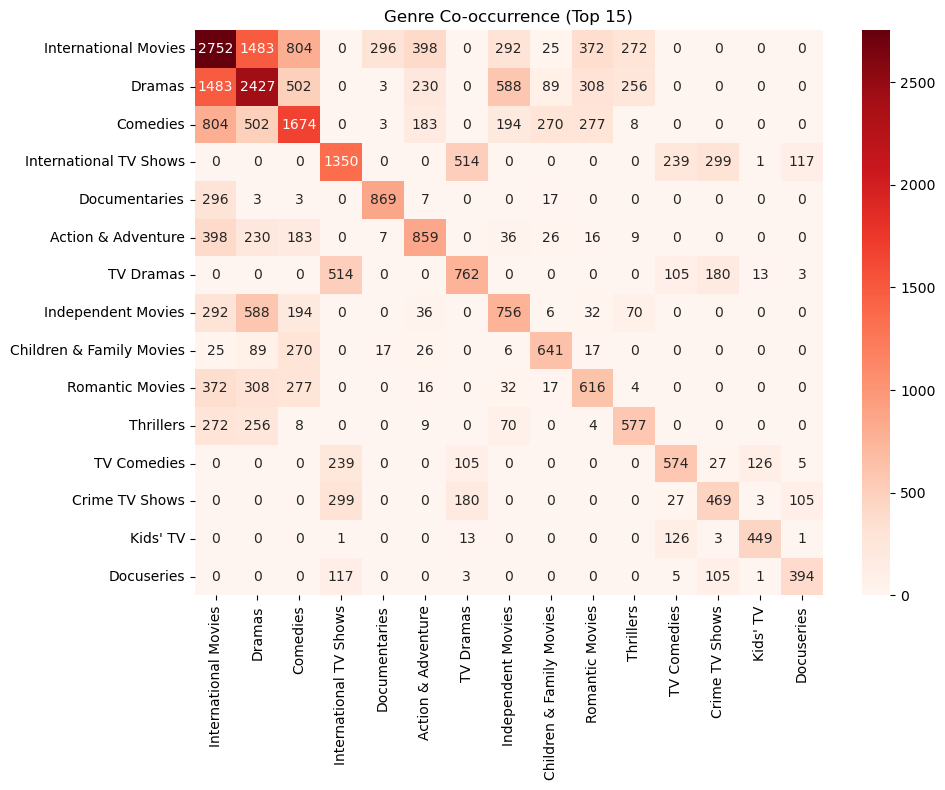

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, r2_score

SEED = 42

def header(text):
    print(f"\n{'='*20} {text} {'='*20}\n")

header("B3. TITLES - MACHINE LEARNING")

# 1. Load Data correctly
titles = pd.read_csv("netflix_titles_clean.csv")
churn = pd.read_csv("netflix_customer_churn_clean.csv")

# 2. Extract duration numeric values if not already present
if "duration_value" not in titles.columns and "duration" in titles.columns:
    titles["duration_value"] = titles["duration"].str.extract(r"(\d+)").astype(float)

# Feature Engineering
mdf = titles.dropna(subset=["year_added"]).copy()
mdf["n_genres"] = mdf["listed_in"].str.count(",") + 1

# Safely handle missing or non-string cast entries
mdf["n_cast"] = mdf["cast"].apply(
    lambda s: 0 if pd.isna(s) or s == "Unknown" else str(s).count(",") + 1
)

mdf["main_country"] = mdf["country"].fillna("Unknown").str.split(", ").str[0]
top_c = mdf["main_country"].value_counts().head(15).index
mdf["main_country"] = mdf["main_country"].where(mdf["main_country"].isin(top_c), "Other")

mdf["has_director"] = ((mdf["director"].notna()) & (mdf["director"] != "Unknown")).astype(int)

# Column Specifications
Xn = ["release_year", "year_added", "n_genres", "n_cast", "has_director"]
Xc = ["rating", "main_country"]

# Target and Predictors setup
Xt = mdf[Xn + Xc + ["description"]].copy()
# Ensure string type for text vectorizer
Xt["description"] = Xt["description"].fillna("") 
yt = (mdf["type"] == "TV Show").astype(int)

Xtr, Xte, ytr, yte = train_test_split(Xt, yt, test_size=0.25, stratify=yt, random_state=SEED)

# Machine Learning Model 1: Classification (Movie vs TV Show)
pre2 = ColumnTransformer([
    ("num", StandardScaler(), Xn),
    ("cat", OneHotEncoder(handle_unknown="ignore"), Xc),
    ("txt", TfidfVectorizer(max_features=3000, stop_words="english"), "description")
])

clf = Pipeline([
    ("pre", pre2), 
    ("m", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

clf.fit(Xtr, ytr)
p = clf.predict_proba(Xte)[:, 1]

print(f"Movie vs TV Show (LogReg + TF-IDF): acc={accuracy_score(yte, clf.predict(Xte)):.3f} "
      f"AUC={roc_auc_score(yte, p):.3f}")
print(classification_report(yte, clf.predict(Xte), target_names=["Movie", "TV Show"]))

# ---- ML 2: Predict Movie Runtime (Regression)
mv = mdf[(mdf["type"] == "Movie") & (mdf["duration_value"].notna())].copy()
Xr = mv[Xn + Xc]
yr = mv["duration_value"]

Xtr, Xte, ytr, yte = train_test_split(Xr, yr, test_size=0.25, random_state=SEED)

pre3 = ColumnTransformer([
    ("num", StandardScaler(), Xn),
    ("cat", OneHotEncoder(handle_unknown="ignore"), Xc)
])

reg = Pipeline([
    ("pre", pre3), 
    ("m", RandomForestRegressor(300, min_samples_leaf=5, random_state=SEED, n_jobs=-1))
]).fit(Xtr, ytr)

print(f"Movie runtime regression (RF): R2={r2_score(yte, reg.predict(Xte)):.3f}")

# ---- Genre Co-occurrence Analysis
# Recreating the 'genres' dataframe from listed_in comma-separated strings
genres_split = mdf[["show_id", "listed_in"]].dropna()
genres_split["g"] = genres_split["listed_in"].str.split(", ")
genres = genres_split.explode("g")

gm = pd.get_dummies(genres.set_index("show_id")["g"]).groupby(level=0).max().astype(int)
top_g = gm.sum().sort_values(ascending=False).head(15).index
co = gm[top_g].T.dot(gm[top_g])

plt.figure(figsize=(10, 8))
sns.heatmap(co, cmap="Reds", annot=True, fmt="d")
plt.title("Genre Co-occurrence (Top 15)")
plt.tight_layout()
plt.savefig("B4_genre_cooccurrence.png")
plt.show()